<a href="https://colab.research.google.com/github/kkokay07/GenomicClass_on_Cloud/blob/master/ML%20in%20genomics/ML_Random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Classification - Practical Implementation

## Brief Introduction
Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction accuracy and control overfitting. Key features:
- Uses bootstrap sampling (random sampling with replacement)
- Creates multiple decision trees
- Combines predictions through voting
- Provides feature importance ranking

In [1]:
# Step 1: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# Set random seed for reproducibility
np.random.seed(42)

In [3]:
# Step 2: Load and Preview Data
data = pd.read_csv('common_cancers.csv')  # Replace with your data file

print("Dataset Shape:", data.shape)
print("\nFirst few rows:")
display(data.head())

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

Dataset Shape: (262, 646)

First few rows:


,Individuals,HD0100001401,BFGL-NGS-62077,HD0100002373,HD0100010085,HD0100012520,HD0100015487,HD0100015803,HD0100016678,HD0100016761,...,HD2800008319,HD2800009580,HD2800010158,HD2800011791,BFGL-NGS-32198,HD2900014986,HD2900005308,HD2900015344,HD2900015407,HD2900012940
0,Lung_Cancer,1,1,1,1,1,1,3,3,3,...,3,3,1,3,1,3,1,3,1,3
1,Lung_Cancer,1,2,1,1,1,1,3,3,3,...,3,3,1,3,1,3,1,3,1,3
2,Lung_Cancer,1,2,1,1,1,1,3,3,3,...,3,3,1,3,1,3,1,3,1,3
3,Lung_Cancer,1,1,1,1,1,1,3,3,3,...,3,3,1,3,1,3,1,3,1,3
4,Lung_Cancer,1,1,1,1,1,1,3,3,3,...,3,3,1,3,1,3,1,3,1,3



Missing Values:
Individuals       0
HD0100001401      0
BFGL-NGS-62077    0
HD0100002373      0
HD0100010085      0
                 ..
HD2900014986      0
HD2900005308      0
HD2900015344      0
HD2900015407      0
HD2900012940      0
Length: 646, dtype: int64


In [6]:
# Step 3: Data Preprocessing

# Separate features and target
X = data.drop('Individuals', axis=1)  # Replace 'target' with your target column name
y = data['Individuals']

# Encode categorical target if needed
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (209, 645)
Testing set shape: (53, 645)


In [7]:
# Step 4: Create and Train Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,        # Number of trees
    max_features='sqrt',     # Number of features to consider at each split
    max_depth=None,          # Maximum depth of the trees
    min_samples_split=2,     # Minimum samples required to split an internal node
    min_samples_leaf=1,      # Minimum samples required to be at a leaf node
    bootstrap=True,          # Use bootstrap samples
    random_state=42,         # Random state for reproducibility
    n_jobs=-1               # Use all available cores
)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

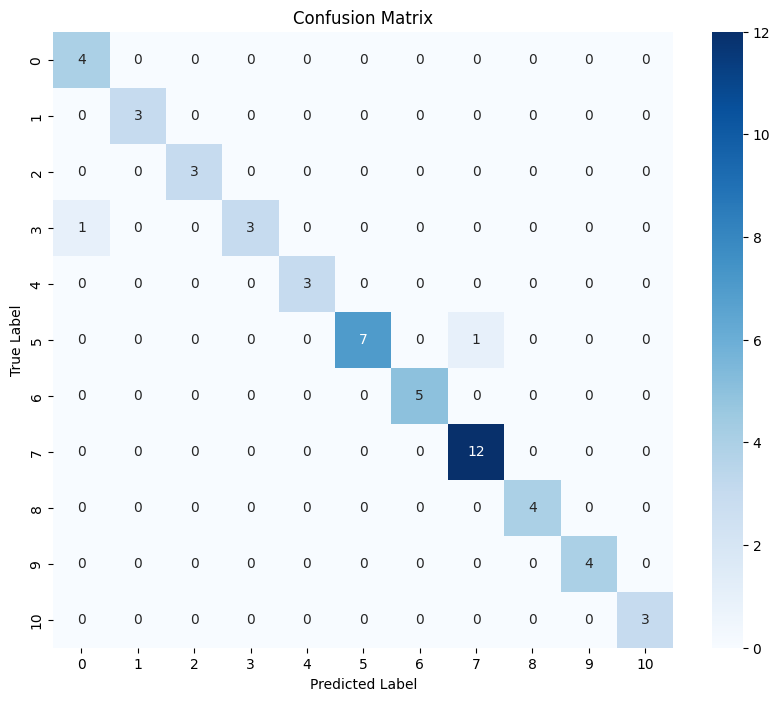


Classification Report:
                   precision    recall  f1-score   support

    Breast_Cancer       0.80      1.00      0.89         4
Colorectal_Cancer       1.00      1.00      1.00         3
Esophageal_Cancer       1.00      1.00      1.00         3
   Gastric_Cancer       1.00      0.75      0.86         4
    Kidney_Cancer       1.00      1.00      1.00         3
     Liver_Cancer       1.00      0.88      0.93         8
      Lung_Cancer       1.00      1.00      1.00         5
        No_Cancer       0.92      1.00      0.96        12
Pancreatic_Cancer       1.00      1.00      1.00         4
  Prostate_Cancer       1.00      1.00      1.00         4
      Skin_Cancer       1.00      1.00      1.00         3

         accuracy                           0.96        53
        macro avg       0.97      0.97      0.97        53
     weighted avg       0.97      0.96      0.96        53



In [8]:
# Step 5: Make Predictions and Evaluate

# Make predictions
y_pred = rf_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                          target_names=label_encoder.classes_))

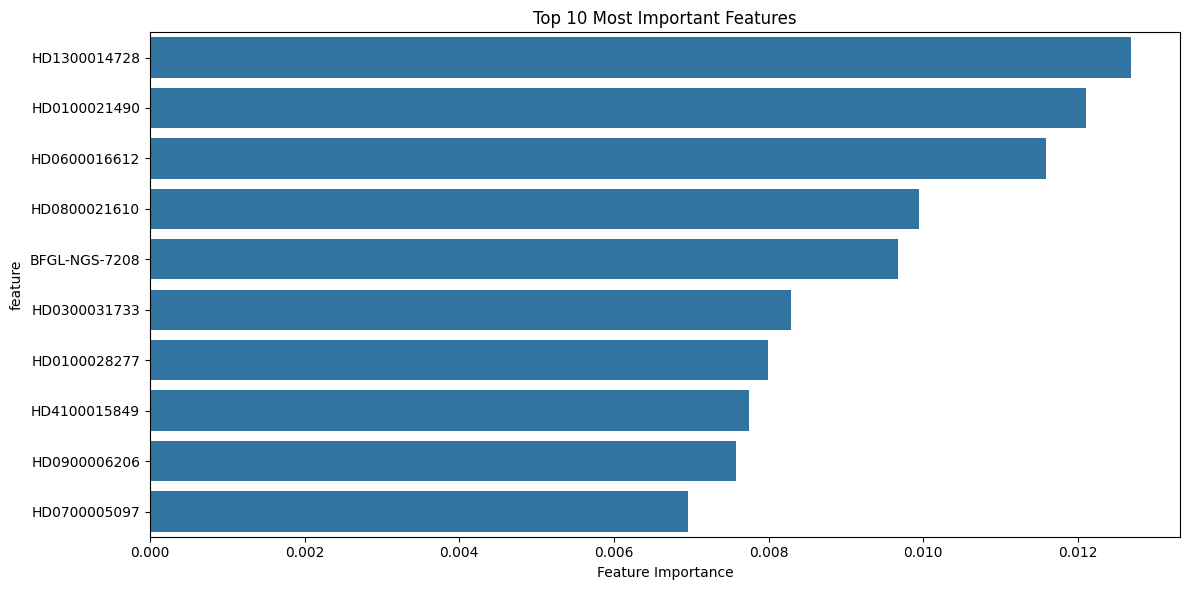


Top 10 Feature Importances:
           feature  importance
381   HD1300014728    0.012684
13    HD0100021490    0.012102
191   HD0600016612    0.011582
254   HD0800021610    0.009944
384  BFGL-NGS-7208    0.009669
90    HD0300031733    0.008287
18    HD0100028277    0.007995
569   HD4100015849    0.007750
267   HD0900006206    0.007580
206   HD0700005097    0.006963


In [9]:
# Step 6: Feature Importance Analysis

# Get feature importances
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values('importance',
                                                   ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature',
            data=feature_importance.head(10))
plt.title('Top 10 Most Important Features')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

# Print importance values
print("\nTop 10 Feature Importances:")
print(feature_importance.head(10))

In [10]:
# Step 7: Save Model (Optional)
import joblib

# Save the model
joblib.dump(rf_model, 'random_forest_model.joblib')

# Save the label encoder
joblib.dump(label_encoder, 'label_encoder.joblib')

print("Model and label encoder saved successfully!")

Model and label encoder saved successfully!


## Step 8: Predict New Samples

Now, let's load the saved model and label encoder to make predictions on new, unseen data.

In [ ]:
import joblib
import pandas as pd
import numpy as np

# Load the saved model and label encoder
loaded_rf_model = joblib.load('random_forest_model.joblib')
loaded_label_encoder = joblib.load('label_encoder.joblib')

print("Model and label encoder loaded successfully!")

In [16]:
import pandas as pd
samples = pd.read_csv("Samples.csv")
predictions_encoded = loaded_rf_model.predict(samples)
predictions_decoded = loaded_label_encoder.inverse_transform(predictions_encoded)
for i, prediction in enumerate(predictions_decoded):
    print(f"Sample {i+1}: {prediction}")

   HD0100001401  BFGL-NGS-62077  HD0100002373  HD0100010085  HD0100012520  \
0             1               1             1             1             1   
1             3               3             3             3             3   
2             3               3             1             3             3   
3             1               1             1             1             1   

   HD0100015487  HD0100015803  HD0100016678  HD0100016761  HD0100017653  ...  \
0             1             3             3             3             3  ...   
1             1             1             0             1             2  ...   
2             3             1             0             1             1  ...   
3             1             2             3             3             3  ...   

   HD2800008319  HD2800009580  HD2800010158  HD2800011791  BFGL-NGS-32198  \
0             3             3             1             3               1   
1             3             1             3             1  